# 09. Weather Feature Modeling

This notebook tests whether calendar and weather context features improve lotto prediction beyond the existing temporal baseline features.

Comparison strategy:

- `base`: existing temporal frequency + gap features
- `base_plus_calendar`: base + calendar context derived from draw date
- `base_plus_calendar_weather`: base + calendar + weather context
- `calendar_weather_only`: context-only reference model

The main goal is not to claim strong predictability, but to measure incremental value from contextual variables under the same time-based split.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
APP_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "src" / "notebook_support.py").exists() and (candidate / "data").exists():
        APP_ROOT = candidate
        break
    if (candidate / "app" / "src" / "notebook_support.py").exists() and (candidate / "app" / "data").exists():
        APP_ROOT = candidate / "app"
        break

if APP_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

from src.notebook_support import describe_notebook_environment
describe_notebook_environment(APP_ROOT)


{'app_root': '/workspace', 'cwd': '/workspace/notebooks'}

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.features import build_model_feature_bundle, describe_feature_sets, load_weather_context
from src.features.temporal_features import time_based_train_test_split
from src.models.train_baseline import build_logistic_regression_model
from src.models.model_suite import LABEL_COLS, evaluate_probability_model
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)


## Configuration

In [3]:
WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
BACKTEST_INITIAL_TRAIN_SIZE = 600
BACKTEST_TEST_SIZE = 30
BACKTEST_STEP_SIZE = 30
MAX_BACKTEST_FOLDS = 12  # keep this notebook reasonably fast


## Load Base Datasets

In [4]:
weather_df = load_weather_context()
feature_bundle = build_model_feature_bundle(window=WINDOW, save_base=False, weather_df=weather_df)
clean_df = feature_bundle.clean_df
y = feature_bundle.y.reset_index(drop=True)

X_calendar = feature_bundle.context[feature_bundle.calendar_feature_cols].reset_index(drop=True)
X_weather = feature_bundle.context[feature_bundle.weather_feature_cols].reset_index(drop=True)
X_feature_sets = {
    "base": feature_bundle.feature_sets["base"],
    "base_plus_calendar": pd.concat([feature_bundle.base.reset_index(drop=True), X_calendar], axis=1),
    "base_plus_calendar_weather": feature_bundle.feature_sets["base_plus_context"],
    "calendar_weather_only": pd.concat([X_calendar, X_weather], axis=1),
}

clean_df.shape, weather_df.shape, {k: v.shape for k, v in X_feature_sets.items()}


((1222, 18),
 (1217, 24),
 {'base': (1202, 90),
  'base_plus_calendar': (1202, 99),
  'base_plus_calendar_weather': (1202, 121),
  'calendar_weather_only': (1202, 31)})

## Build Labels and Base Feature Matrix

In [5]:
feature_bundle.target_rounds.head()


0    21
1    22
2    23
3    24
4    25
Name: round, dtype: int64

## Calendar and Weather Feature Blocks

In [6]:
feature_bundle.calendar_feature_cols, feature_bundle.weather_feature_cols[:8]


(['month_sin',
  'month_cos',
  'day_sin',
  'day_cos',
  'year',
  'season_spring',
  'season_summer',
  'season_autumn',
  'season_winter'],
 ['temp_at_draw',
  'humidity_at_draw',
  'wind_at_draw',
  'pressure_at_draw',
  'precip_at_draw',
  'precip_day_cumulative_at_draw',
  'precip_1h',
  'precip_6h'])

## Align Context Features to Target Rounds

In [7]:
describe_feature_sets(feature_bundle)


,feature_set,n_features,description
0,base,90,Rolling frequency and gap features only.
1,base_plus_pattern,118,Base features plus draw-level internal pattern...
2,base_plus_context,121,Base features plus calendar and weather context.
3,full_feature_set,149,"Base, internal pattern, and context features c..."


## Holdout Comparison

In [8]:
def evaluate_logistic_feature_set(X_frame, y_frame, feature_set_name):
    split = time_based_train_test_split(X_frame, y_frame, test_ratio=TEST_RATIO)
    model = build_logistic_regression_model(random_seed=RANDOM_SEED)
    model.fit(split["X_train"], split["y_train"])
    result = evaluate_probability_model(feature_set_name, model, split["X_test"], split["y_test"])
    row = {
        "feature_set": feature_set_name,
        "subset_accuracy": result["subset_accuracy"],
        "number_level_accuracy": result["number_level_accuracy"],
        "avg_hit": result["avg_hit"],
        "hit_std": result["hit_std"],
        "n_train_rows": len(split["X_train"]),
        "n_test_rows": len(split["X_test"]),
    }
    return row

holdout_rows = []
for feature_set_name, X_frame in X_feature_sets.items():
    holdout_rows.append(evaluate_logistic_feature_set(X_frame, y.reset_index(drop=True), feature_set_name))

holdout_feature_summary = pd.DataFrame(holdout_rows).sort_values("avg_hit", ascending=False).reset_index(drop=True)
holdout_feature_summary

,feature_set,subset_accuracy,number_level_accuracy,avg_hit,hit_std,n_train_rows,n_test_rows
0,base,0.0,0.772430,0.879668,0.843600,961,241
1,base_plus_calendar,0.0,0.772245,0.875519,0.840533,961,241
2,base_plus_calendar_weather,0.0,0.771508,0.858921,0.802494,961,241
3,calendar_weather_only,0.0,0.768373,0.788382,0.815329,961,241


/tmp/ipykernel_2529/3752211619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holdout_feature_summary, x="feature_set", y="avg_hit", palette="viridis", ax=ax)


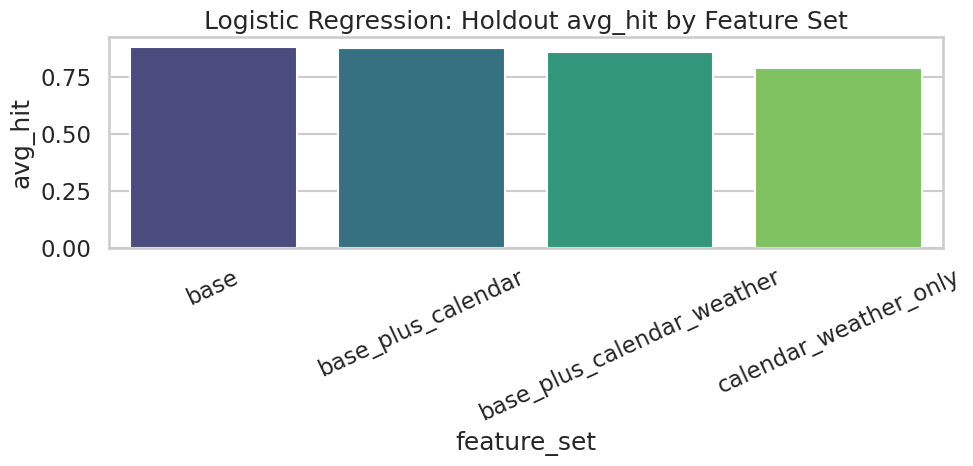

In [9]:
fig_feature_holdout, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=holdout_feature_summary, x="feature_set", y="avg_hit", palette="viridis", ax=ax)
ax.set_title("Logistic Regression: Holdout avg_hit by Feature Set")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## Rolling Backtest Comparison

In [10]:
def run_feature_backtest(X_frame, y_frame, feature_set_name):
    rows = []
    for fold_idx, train_end in enumerate(range(BACKTEST_INITIAL_TRAIN_SIZE, len(X_frame) - BACKTEST_TEST_SIZE + 1, BACKTEST_STEP_SIZE)):
        if MAX_BACKTEST_FOLDS is not None and fold_idx >= MAX_BACKTEST_FOLDS:
            break
        test_end = train_end + BACKTEST_TEST_SIZE
        X_train_fold = X_frame.iloc[:train_end].reset_index(drop=True)
        y_train_fold = y_frame.iloc[:train_end].reset_index(drop=True)
        X_test_fold = X_frame.iloc[train_end:test_end].reset_index(drop=True)
        y_test_fold = y_frame.iloc[train_end:test_end].reset_index(drop=True)
        model = build_logistic_regression_model(random_seed=RANDOM_SEED)
        model.fit(X_train_fold, y_train_fold)
        result = evaluate_probability_model(feature_set_name, model, X_test_fold, y_test_fold)
        rows.append({
            "fold": fold_idx,
            "feature_set": feature_set_name,
            "subset_accuracy": result["subset_accuracy"],
            "number_level_accuracy": result["number_level_accuracy"],
            "avg_hit": result["avg_hit"],
        })
    return pd.DataFrame(rows)

backtest_results = []
for feature_set_name, X_frame in X_feature_sets.items():
    backtest_results.append(run_feature_backtest(X_frame, y.reset_index(drop=True), feature_set_name))

backtest_feature_results = pd.concat(backtest_results, ignore_index=True)
backtest_feature_summary = backtest_feature_results.groupby("feature_set", as_index=False).agg(
    folds=("fold", "nunique"),
    mean_subset_accuracy=("subset_accuracy", "mean"),
    mean_number_level_accuracy=("number_level_accuracy", "mean"),
    mean_avg_hit=("avg_hit", "mean"),
    std_avg_hit=("avg_hit", "std"),
).sort_values("mean_avg_hit", ascending=False).reset_index(drop=True)

backtest_feature_summary

,feature_set,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,std_avg_hit
0,base_plus_calendar,12,0.0,0.770123,0.827778,0.117923
1,base_plus_calendar_weather,12,0.0,0.769383,0.811111,0.110402
2,base,12,0.0,0.769136,0.805556,0.118776
3,calendar_weather_only,12,0.0,0.767160,0.761111,0.113559


/tmp/ipykernel_2529/83556522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=backtest_feature_summary, x="feature_set", y="mean_avg_hit", palette="mako", ax=ax)


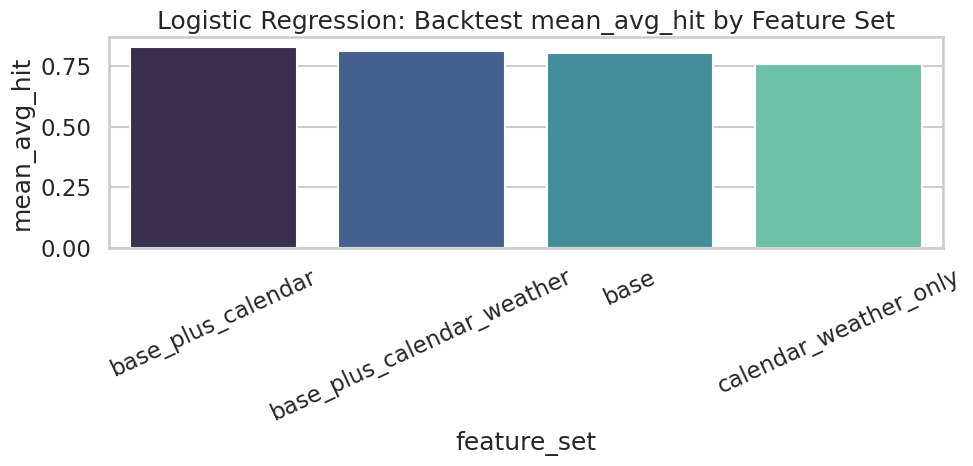

In [11]:
fig_feature_backtest, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=backtest_feature_summary, x="feature_set", y="mean_avg_hit", palette="mako", ax=ax)
ax.set_title("Logistic Regression: Backtest mean_avg_hit by Feature Set")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

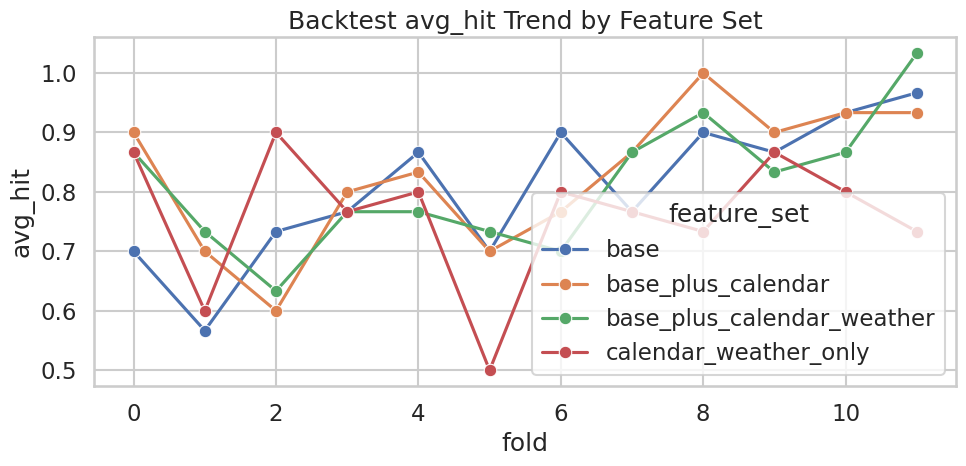

In [12]:
fig_feature_trend, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=backtest_feature_results, x="fold", y="avg_hit", hue="feature_set", marker="o", ax=ax)
ax.set_title("Backtest avg_hit Trend by Feature Set")
plt.tight_layout()
plt.show()

## Interpretation Notes

In [13]:
comparison_cols = [
    "feature_set",
    "avg_hit",
    "number_level_accuracy",
]
holdout_feature_summary[comparison_cols]

,feature_set,avg_hit,number_level_accuracy
0,base,0.879668,0.772430
1,base_plus_calendar,0.875519,0.772245
2,base_plus_calendar_weather,0.858921,0.771508
3,calendar_weather_only,0.788382,0.768373


Use the results with a conservative interpretation:

- if `base_plus_calendar_weather` is only marginally better than `base`, the added context may be interesting but not strongly predictive
- if `calendar_weather_only` performs much worse than `base`, then context is acting as a weak auxiliary signal rather than a standalone predictor
- backtest results matter more than a single holdout split when judging robustness


## Report Export

In [14]:
save_report_figure(fig_feature_holdout, "fig_26_weather_feature_holdout_comparison.png")
save_report_figure(fig_feature_backtest, "fig_27_weather_feature_backtest_comparison.png")
save_report_figure(fig_feature_trend, "fig_28_weather_feature_backtest_trend.png")

save_report_table(holdout_feature_summary, "table_20_weather_feature_holdout_summary.csv")
save_report_table(backtest_feature_summary, "table_21_weather_feature_backtest_summary.csv")
save_report_table(backtest_feature_results, "table_22_weather_feature_backtest_results.csv")
print("Saved weather feature modeling report artifacts.")

Saved weather feature modeling report artifacts.
